In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import numpy as np

In [2]:
data_dir = 'data/clean_train'  # Replace with the path to your main directory
img_height = 224
img_width = 224
batch_size = 32
epochs = 50  # Adjust as needed
validation_split = 0.2  # Percentage of data for validation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=validation_split  
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Assuming you have subdirectories for each class
    subset='training',
    shuffle=True,
    seed=42
)

Found 968 images belonging to 12 classes.


In [5]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 242 images belonging to 12 classes.


In [6]:
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
class_counts = np.bincount(train_generator.classes)
print(f"Class labels: {class_labels}")
print(f"Number of classes: {num_classes}")
print(f"Class counts: {class_counts}")

Class labels: ['abstract_graphic', 'animals', 'birds', 'checks', 'damasks', 'floral', 'geometric', 'kids', 'leaf_trees', 'plains_textures', 'spots', 'stripes']
Number of classes: 12
Class counts: [80 80 80 80 80 88 80 80 80 80 80 80]


In [7]:
from collections import Counter

counter = Counter(train_generator.classes)
max_count = float(max(counter.values()))
class_weights = {class_id: max_count / count for class_id, count in counter.items()}
print(class_weights)

{np.int32(0): 1.1, np.int32(1): 1.1, np.int32(2): 1.1, np.int32(3): 1.1, np.int32(4): 1.1, np.int32(5): 1.0, np.int32(6): 1.1, np.int32(7): 1.1, np.int32(8): 1.1, np.int32(9): 1.1, np.int32(10): 1.1, np.int32(11): 1.1}


In [8]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
# x = Dropout(0.2)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [11]:
model = Model(inputs=base_model.input, outputs=predictions)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00008)  # Adjust learning rate as needed
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=10,            # Stop after 10 epochs of no improvement
    min_delta=0.001,        # Minimum change to be considered an improvement
    mode='min',             # We want the validation loss to minimize
    verbose=1,              # Print a message when it stops
    restore_best_weights=True # Restore model weights from the epoch with the best val_loss
)

class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, accuracy_threshold=0.90, val_accuracy_threshold=0.90):
        super().__init__()
        self.accuracy_threshold = accuracy_threshold
        self.val_accuracy_threshold = val_accuracy_threshold
        print(f"Accuracy Threshold Callback initialized: Train Acc >= {accuracy_threshold*100}% and Val Acc >= {val_accuracy_threshold*100}%")

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('accuracy')
        current_val_acc = logs.get('val_accuracy')

        if current_acc is None or current_val_acc is None:
            print("Warning: 'accuracy' or 'val_accuracy' not found in logs. Cannot check thresholds.")
            return

        if current_acc >= self.accuracy_threshold and current_val_acc >= self.val_accuracy_threshold:
            print(f"\nEpoch {epoch+1}: Reached desired accuracy threshold!")
            print(f"  Train Acc: {current_acc:.4f}, Val Acc: {current_val_acc:.4f}")
            self.model.stop_training = True

In [14]:
my_callbacks = [
    AccuracyThresholdCallback(accuracy_threshold=0.95, val_accuracy_threshold=0.95),
    early_stopping_callback
]

Accuracy Threshold Callback initialized: Train Acc >= 95.0% and Val Acc >= 95.0%


In [15]:
history = model.fit(
    train_generator,
    # steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    # validation_steps=validation_generator.samples // batch_size,  
    verbose=1,
    class_weight=class_weights,
    callbacks=my_callbacks
)

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.2250 - loss: 2.5031 - val_accuracy: 0.4752 - val_loss: 1.6911
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5632 - loss: 1.5499 - val_accuracy: 0.5744 - val_loss: 1.3073
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7021 - loss: 1.1329 - val_accuracy: 0.6364 - val_loss: 1.1584
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7896 - loss: 0.8927 - val_accuracy: 0.6364 - val_loss: 1.1798
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.8291 - loss: 0.7443 - val_accuracy: 0.6570 - val_loss: 1.0504
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8148 - loss: 0.7175 - val_accuracy: 0.6818 - val_loss: 1.0498
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8215 - loss: 0.6745 - val_accuracy: 0.6653 - val_loss: 1.0112
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8658 - loss: 0.5624 - val_accuracy: 0.6901 - val_loss:

In [16]:
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6225 - loss: 1.2707
Validation Loss: 0.9431
Validation Accuracy: 0.7143


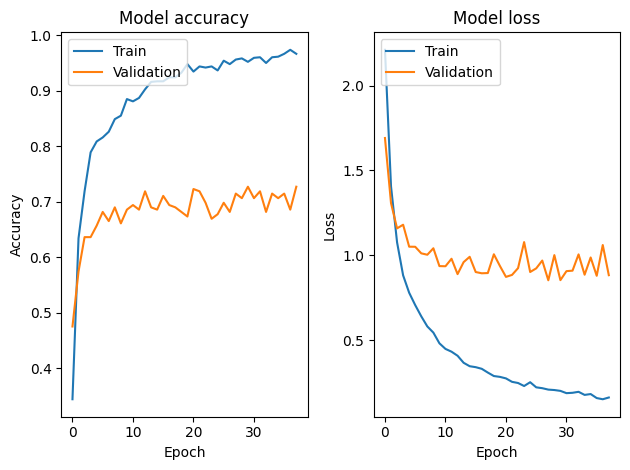

In [17]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
model.save('models/whole_pattern_model_1.h5')

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
model_path = "models/whole_pattern_model_1.h5"
model_1 = tf.keras.models.load_model(model_path)

In [20]:
# --- 3. Make Predictions on the Validation Set ---
print("Making predictions on the validation set...")
# Predict probabilities for each class
y_pred_probs = model_1.predict(validation_generator, steps=validation_generator.samples // batch_size + 1)
# Convert probabilities to class labels (index of the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from the generator
# The generator provides labels in the order it processes the data
y_true = validation_generator.classes
class_names = list(validation_generator.class_indices.keys())
print("\n--- Classification Report ---")
# target_names: provides meaningful labels for the report
# digits: number of decimal places for floating point values
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)

Making predictions on the validation set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step

--- Classification Report ---
                  precision    recall  f1-score   support

abstract_graphic     0.6154    0.4000    0.4848        20
         animals     0.7692    0.5000    0.6061        20
           birds     1.0000    0.1000    0.1818        20
          checks     1.0000    1.0000    1.0000        20
         damasks     1.0000    0.6500    0.7879        20
          floral     0.2881    0.7727    0.4198        22
       geometric     0.8571    0.6000    0.7059        20
            kids     0.9333    0.7000    0.8000        20
      leaf_trees     0.5000    0.7500    0.6000        20
 plains_textures     0.7500    0.9000    0.8182        20
           spots     1.0000    0.9500    0.9744        20
         stripes     0.9000    0.9000    0.9000        20

        accuracy                         0.6860       242
       macro avg     0.8011    0.6852    0.6899       242
    weighted avg

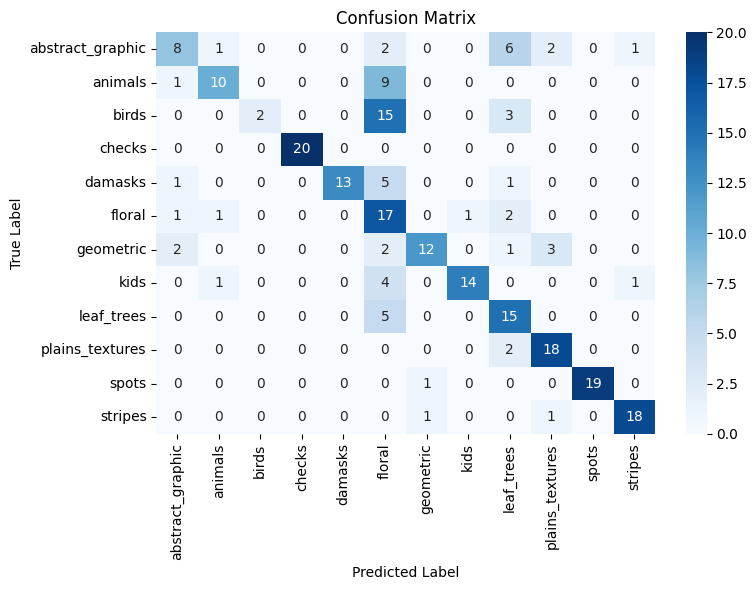

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
model2 = 